# 5. Profit-Maximizing Threshold Analysis

### Outline of this notebook:
* **Section 1:** Objective
* **Section 2:** Load Predictions
* **Section 3:** Profit Framework
  * 3.1: Define profit parameters
  * 3.2: Profit curve by threshold
  * 3.3: Optimal threshold
* **Section 4:** Sensitivity Analysis
  * 4.1: Sensitivity to LGD
  * 4.2: Sensitivity to interest rate (revenue)
* **Section 5:** Comparison of Thresholds

---
## Section 1: Objective

Standard classification thresholds (e.g., F1-optimal) treat false positives and false negatives symmetrically in terms of model performance, but this is not how lenders actually make decisions. In practice, the cost of a missed default (approving a loan that defaults) and the cost of a false rejection (denying a loan that would have been repaid) are asymmetric and can be quantified in dollar terms.

This notebook frames the threshold decision as a **profit maximization problem**:

- **Approve a loan (predict non-default):**
  - If the borrower repays → the lender earns interest revenue
  - If the borrower defaults → the lender loses the outstanding principal (scaled by LGD)
- **Deny a loan (predict default):**
  - No revenue, no loss (opportunity cost not modeled)

By sweeping over all possible thresholds and computing the expected profit at each, we identify the threshold that **maximizes total profit** on the test set — and compare it to the F1-optimal and default (0.5) thresholds.

This reframes the model as a **lending decision tool** rather than a pure classification exercise.

> **Note:** Profit parameters (interest rate, LGD) are assumed and simplified. In practice these vary by loan and would be modeled explicitly.

---
## Section 2: Load Predictions

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json

In [5]:
# Load test predictions from logistic full model (saved in notebook 4a)
preds = pd.read_parquet("../outputs/logistic_full_test_predictions.parquet")
y_true = preds["y_true"].values
y_proba = preds["y_pred_proba"].values

# Load F1-optimal threshold
with open("../outputs/threshold.json") as f:
    threshold_f1 = json.load(f)["threshold"]

print(f"Test set size: {len(y_true):,}")
print(f"Default rate:  {y_true.mean():.3f}")
print(f"F1-optimal threshold: {threshold_f1:.4f}")

Test set size: 371,296
Default rate:  0.227
F1-optimal threshold: 0.2097


---
## Section 3: Profit Framework

### 🔷 3.1: Define profit parameters

We use a simplified per-loan profit model:

| Decision | Outcome | Profit |
|---|---|---|
| Approve (predict non-default) | Borrower repays | `+revenue` |
| Approve (predict non-default) | Borrower defaults | `−loss` |
| Deny (predict default) | Either | `0` |

Where:
- `revenue` = interest income earned if the loan is repaid (proxy: average interest rate × loan amount, normalized to 1)
- `loss` = principal lost if the borrower defaults, scaled by LGD (Loss Given Default)

Since we don't have per-loan amounts in this simplified analysis, we normalize and work in **per-unit terms**:
- `revenue = r` (e.g., 0.12 = 12% of loan amount)
- `loss = LGD` (e.g., 0.60 = 60% of loan amount recovered)

These are reasonable industry defaults for unsecured consumer loans.

In [7]:
# Profit parameters (per unit of loan amount)
REVENUE = 0.12   # interest income if loan is repaid (12% of principal)
LGD     = 0.60   # loss given default (60% of principal lost)

print(f"Revenue per good loan:  +{REVENUE:.0%}")
print(f"Loss per bad loan:      -{LGD:.0%}")
print(f"Break-even default rate: {REVENUE / (REVENUE + LGD):.1%}")
print()
print("A loan is worth approving if P(default) < break-even rate,")
print("i.e. expected profit = REVENUE*(1-p) - LGD*p > 0")

Revenue per good loan:  +12%
Loss per bad loan:      -60%
Break-even default rate: 16.7%

A loan is worth approving if P(default) < break-even rate,
i.e. expected profit = REVENUE*(1-p) - LGD*p > 0


### 🔷 3.2: Profit curve by threshold

For each threshold `t`, we compute the total profit on the test set:
- Approve loans where `P(default) < t` (predict non-default)
- For approved loans: earn `REVENUE` if repaid, lose `LGD` if defaulted

In [9]:
thresholds = np.linspace(0.01, 0.99, 200)
profits = []
n_approved = []

for t in thresholds:
    approved = y_proba < t  # approve if predicted default prob is below threshold
    profit = np.where(
        approved,
        np.where(y_true == 0, REVENUE, -LGD),  # approved: earn or lose
        0.0                                      # denied: no profit/loss
    ).sum()
    profits.append(profit)
    n_approved.append(approved.sum())

profits    = np.array(profits)
n_approved = np.array(n_approved)

# Normalize to per-loan-approved profit for interpretability
profit_per_loan = np.where(n_approved > 0, profits / n_approved, 0)

print(f"Max total profit: {profits.max():,.0f} (at threshold = {thresholds[profits.argmax()]:.3f})")
print(f"Loans approved at that threshold: {n_approved[profits.argmax()]:,} / {len(y_true):,}")

Max total profit: 6,185 (at threshold = 0.158)
Loans approved at that threshold: 139,645 / 371,296


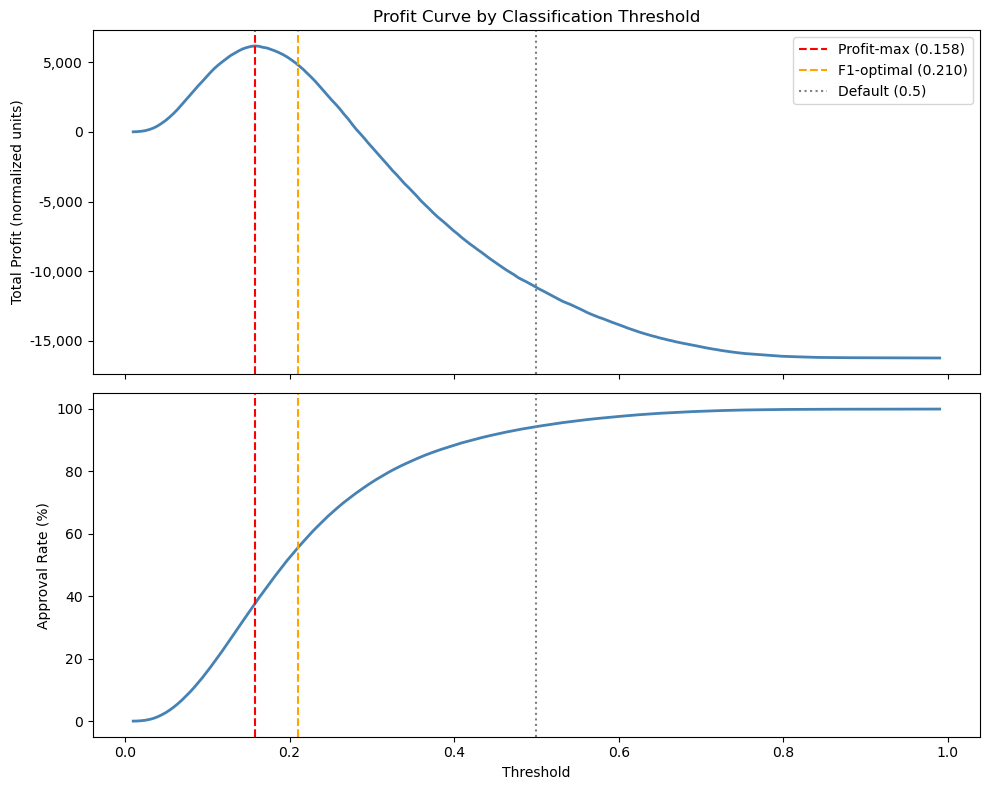

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel 1: Total profit
axes[0].plot(thresholds, profits, color="steelblue", linewidth=2)
axes[0].axvline(thresholds[profits.argmax()], color="red", linestyle="--", label=f"Profit-max ({thresholds[profits.argmax()]:.3f})")
axes[0].axvline(threshold_f1, color="orange", linestyle="--", label=f"F1-optimal ({threshold_f1:.3f})")
axes[0].axvline(0.5, color="gray", linestyle=":", label="Default (0.5)")
axes[0].set_ylabel("Total Profit (normalized units)")
axes[0].set_title("Profit Curve by Classification Threshold")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Panel 2: Number of loans approved
axes[1].plot(thresholds, n_approved / len(y_true) * 100, color="steelblue", linewidth=2)
axes[1].axvline(thresholds[profits.argmax()], color="red", linestyle="--")
axes[1].axvline(threshold_f1, color="orange", linestyle="--")
axes[1].axvline(0.5, color="gray", linestyle=":")
axes[1].set_ylabel("Approval Rate (%)")
axes[1].set_xlabel("Threshold")

plt.tight_layout()
plt.show()

### 🔷 3.3: Optimal threshold — summary table

In [12]:
def evaluate_at_threshold(t, label):
    approved  = y_proba < t
    profit    = np.where(approved, np.where(y_true == 0, REVENUE, -LGD), 0.0).sum()
    n_app     = approved.sum()
    # Among approved: how many actually defaulted?
    default_in_approved = y_true[approved].mean() if n_app > 0 else np.nan
    return {
        "Threshold label": label,
        "Threshold": round(t, 4),
        "Approval rate": f"{n_app / len(y_true):.1%}",
        "Default rate in approved": f"{default_in_approved:.1%}",
        "Total profit": f"{profit:,.0f}",
        "Profit per approved loan": f"{profit / n_app:.4f}" if n_app > 0 else "N/A"
    }

threshold_profit = thresholds[profits.argmax()]

rows = [
    evaluate_at_threshold(threshold_profit, "Profit-maximizing"),
    evaluate_at_threshold(threshold_f1,     "F1-optimal"),
    evaluate_at_threshold(0.5,              "Default (0.5)"),
]

display(pd.DataFrame(rows))

,Threshold label,Threshold,Approval rate,Default rate in approved,Total profit,Profit per approved loan
0,Profit-maximizing,0.1577,37.6%,10.5%,"6,185",0.0443
1,F1-optimal,0.2097,55.5%,13.4%,"4,864",0.0236
2,Default (0.5),0.5000,94.4%,21.1%,"-11,173",-0.0319


---
## Section 4: Sensitivity Analysis

The profit-maximizing threshold depends on the assumed profit parameters. Here we examine how the optimal threshold and total profit change as we vary LGD and the interest revenue rate.

### 🔷 4.1: Sensitivity to LGD

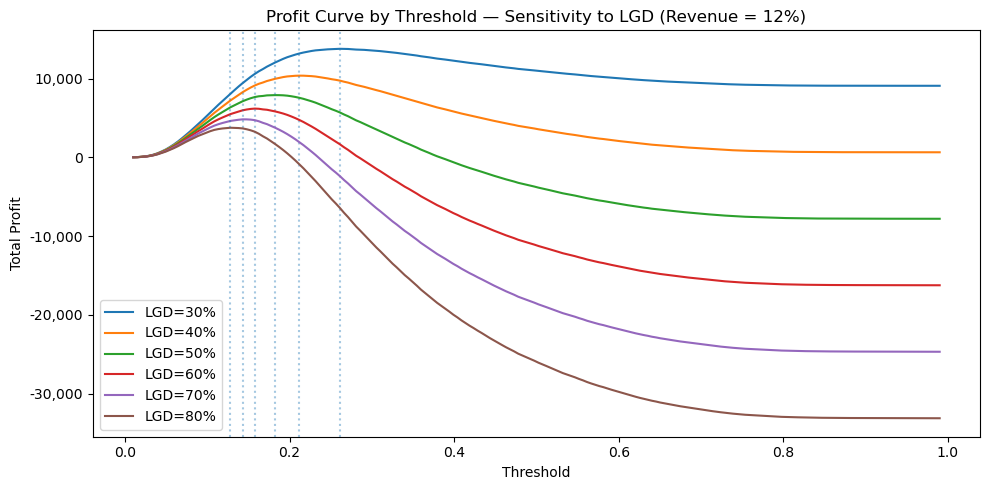

In [14]:
lgd_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

fig, ax = plt.subplots(figsize=(10, 5))

for lgd in lgd_values:
    p = []
    for t in thresholds:
        approved = y_proba < t
        profit = np.where(approved, np.where(y_true == 0, REVENUE, -lgd), 0.0).sum()
        p.append(profit)
    p = np.array(p)
    ax.plot(thresholds, p, label=f"LGD={lgd:.0%}")
    ax.axvline(thresholds[p.argmax()], linestyle=":", alpha=0.4)

ax.set_xlabel("Threshold")
ax.set_ylabel("Total Profit")
ax.set_title(f"Profit Curve by Threshold — Sensitivity to LGD (Revenue = {REVENUE:.0%})")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### 🔷 4.2: Sensitivity to interest rate (revenue)

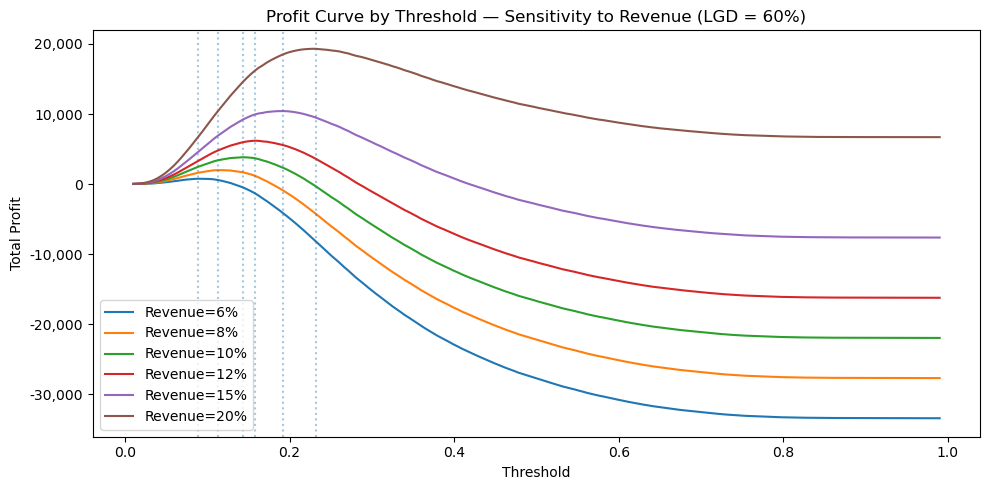

In [16]:
revenue_values = [0.06, 0.08, 0.10, 0.12, 0.15, 0.20]

fig, ax = plt.subplots(figsize=(10, 5))

for rev in revenue_values:
    p = []
    for t in thresholds:
        approved = y_proba < t
        profit = np.where(approved, np.where(y_true == 0, rev, -LGD), 0.0).sum()
        p.append(profit)
    p = np.array(p)
    ax.plot(thresholds, p, label=f"Revenue={rev:.0%}")
    ax.axvline(thresholds[p.argmax()], linestyle=":", alpha=0.4)

ax.set_xlabel("Threshold")
ax.set_ylabel("Total Profit")
ax.set_title(f"Profit Curve by Threshold — Sensitivity to Revenue (LGD = {LGD:.0%})")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

---
## Section 5: Comparison of Thresholds

We compare three operating points:
1. **Profit-maximizing threshold** — maximizes total expected profit under assumed LGD/revenue parameters
2. **F1-optimal threshold** — balances precision and recall (symmetric treatment of errors)
3. **Default threshold (0.5)** — standard classification cutoff

The key insight is that the profit-maximizing threshold is typically **lower** than both the F1-optimal and 0.5 thresholds — meaning it approves more loans. This is because the revenue from good loans (interest) outweighs the loss from a marginal bad loan, so the lender benefits from a more permissive approval policy up to the break-even default rate.

The break-even default rate is:
$$p^* = \frac{r}{r + \text{LGD}}$$

Loans should be approved as long as $P(\text{default}) < p^*$. At `r = 12%` and `LGD = 60%`, this gives $p^* = 16.7\%$.

In [18]:
breakeven = REVENUE / (REVENUE + LGD)
print(f"Break-even default rate: {breakeven:.1%}")
print(f"Profit-max threshold:    {threshold_profit:.4f}")
print(f"F1-optimal threshold:    {threshold_f1:.4f}")
print()
print("The profit-max threshold is close to the break-even default rate.")
print("This is the theoretically correct operating point for a risk-neutral lender.")

Break-even default rate: 16.7%
Profit-max threshold:    0.1577
F1-optimal threshold:    0.2097

The profit-max threshold is close to the break-even default rate.
This is the theoretically correct operating point for a risk-neutral lender.


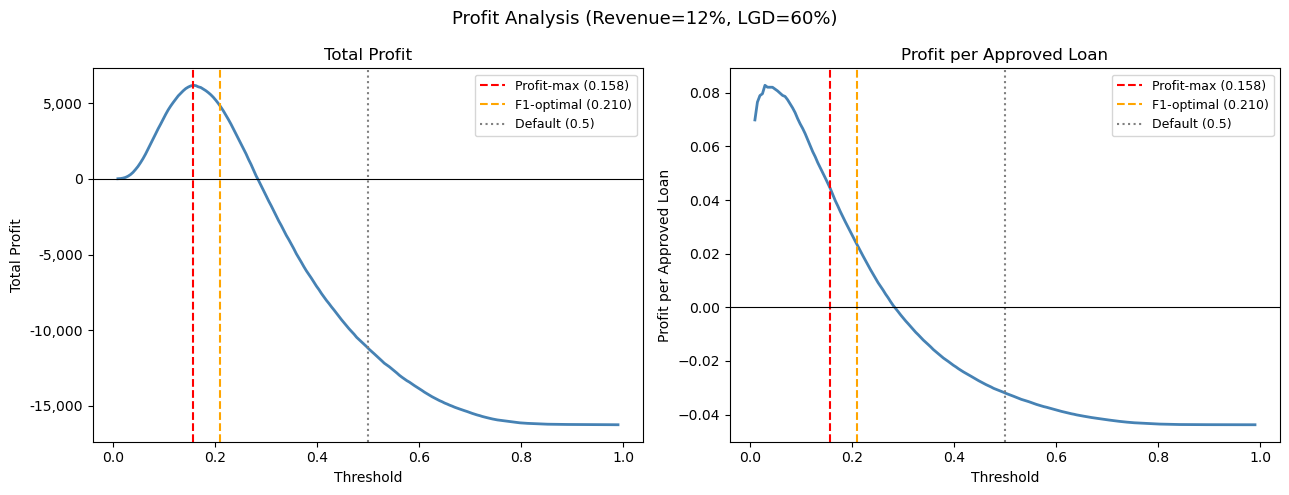

In [19]:
# Profit at each threshold, normalized per approved loan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: total profit
axes[0].plot(thresholds, profits, color="steelblue", linewidth=2)
axes[0].axvline(threshold_profit, color="red",    linestyle="--", label=f"Profit-max ({threshold_profit:.3f})")
axes[0].axvline(threshold_f1,     color="orange", linestyle="--", label=f"F1-optimal ({threshold_f1:.3f})")
axes[0].axvline(0.5,              color="gray",   linestyle=":",  label="Default (0.5)")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="-")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Total Profit")
axes[0].set_title("Total Profit")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Right: profit per approved loan
axes[1].plot(thresholds, profit_per_loan, color="steelblue", linewidth=2)
axes[1].axvline(threshold_profit, color="red",    linestyle="--", label=f"Profit-max ({threshold_profit:.3f})")
axes[1].axvline(threshold_f1,     color="orange", linestyle="--", label=f"F1-optimal ({threshold_f1:.3f})")
axes[1].axvline(0.5,              color="gray",   linestyle=":",  label="Default (0.5)")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="-")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Profit per Approved Loan")
axes[1].set_title("Profit per Approved Loan")
axes[1].legend(fontsize=9)

plt.suptitle(f"Profit Analysis (Revenue={REVENUE:.0%}, LGD={LGD:.0%})", fontsize=13)
plt.tight_layout()
plt.show()